In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# Define file paths
train_file = "data/train.csv"
test_file = "data/test.csv"

print(f"\nProcessing train file: {train_file}")
df_train = pd.read_csv(train_file)

print(f"\nProcessing test file: {test_file}")
df_test = pd.read_csv(test_file)


Processing train file: data/train.csv

Processing test file: data/test.csv


In [2]:
print("Shape df_train : ", df_train.shape)
print("Shape df_test : ", df_test.shape)

df_train = df_train.drop("ID", axis=1)
df_test = df_test.drop("ID", axis=1)
print(df_train.head())

Shape df_train :  (104998, 12)
Shape df_test :  (45002, 11)
       var1  var2  var3      var4     var5  var6  var7  var8  var9  var10  \
0  0.766127    45     2  0.802982   9120.0    13     0     6     0    2.0   
1  0.957151    40     0  0.121876   2600.0     4     0     0     0    1.0   
2  0.658180    38     1  0.085113   3042.0     2     1     0     0    0.0   
3  0.233810    30     0  0.036050   3300.0     5     0     0     0    0.0   
4  0.907239    49     1  0.024926  63588.0     7     0     1     0    0.0   

   TARGET  
0       1  
1       0  
2       0  
3       0  
4       0  


In [3]:
import io
from IPython.display import display, HTML

# Create string buffers to capture info output
buffer1 = io.StringIO()
buffer2 = io.StringIO()

# Write dataframe info to the buffers
df_train.info(buf=buffer1)
df_test.info(buf=buffer2)

# Get the captured output as strings
info1 = buffer1.getvalue()
info2 = buffer2.getvalue()

# Replace spaces with non-breaking spaces and newlines with HTML breaks
info1_html = info1.replace(' ', '&nbsp;').replace('\n', '<br>')
info2_html = info2.replace(' ', '&nbsp;').replace('\n', '<br>')

# Display side by side using HTML
html_content = f"""
<div style="display: flex; font-family: monospace; white-space: pre;">
    <div style="flex: 50%;">
        <h4>Train DataFrame Info</h4>
        {info1_html}
    </div>
    <div style="flex: 50%;">
        <h4>Test DataFrame Info</h4>
        {info2_html}
    </div>
</div>
"""

display(HTML(html_content))

In [4]:
print(f"Proportion of missing var5 in train: {100 - (84226*100/104998)}%")
print(f"Proportion of missing var5 in test: {100 - (36043*100/45002)}%")

print(f"\nProportion of missing var10 in train: {100 - (102238*100/104998)}%")
print(f"Proportion of missing var10 in test: {100 - (43838*100/45002)}%")

Proportion of missing var5 in train: 19.783233966361266%
Proportion of missing var5 in test: 19.908004088707173%

Proportion of missing var10 in train: 2.6286214975523308%
Proportion of missing var10 in test: 2.586551708812948%


About 2500 rows do not have a value for var10 -> delete these rows (only 2% of the data)

About 20000 rows do not have a value for var5 -> deleting these rows might not be suitable, we need to try and see impact on train with validation with:
* delete the rows
* replace with mean or median values
* see if another columns is highly correlated: if yes, then we can delete column var5

(https://www.kaggle.com/discussions/questions-and-answers/396670)

In [5]:
# Quantiles
desc_df = df_train.describe().T
desc_df = desc_df.drop("count", axis=1)
desc_df = desc_df.drop("TARGET", axis=0)
desc_df['type'] = df_train.loc[:, df_train.columns != 'ID'].dtypes
desc_df

,mean,std,min,25%,50%,75%,max,type
var1,6.073156,257.859625,0.0,0.030002,0.155936,0.561917,50708.0,float64
var2,52.261014,14.768987,0.0,41.000000,52.000000,63.000000,107.0,int64
var3,0.422665,4.221443,0.0,0.000000,0.000000,0.000000,98.0,int64
var4,354.627892,2104.703046,0.0,0.175067,0.366162,0.866584,329664.0,float64
var5,6636.738727,13594.929730,0.0,3400.000000,5400.000000,8228.000000,3008750.0,float64
var6,8.442294,5.136260,0.0,5.000000,8.000000,11.000000,58.0,int64
var7,0.268386,4.197747,0.0,0.000000,0.000000,0.000000,98.0,int64
var8,1.018696,1.134364,0.0,0.000000,1.000000,2.000000,54.0,int64
var9,0.242186,4.184389,0.0,0.000000,0.000000,0.000000,98.0,int64
var10,0.757957,1.116196,0.0,0.000000,0.000000,1.000000,20.0,float64


In [6]:
for col in df_train.columns:
    if col == "TARGET":
        continue
    # Get 1st and 99th percentiles
    p01 = df_train[col].quantile(0.0)
    p99 = df_train[col].quantile(0.99)
    
    # Cap values
    df_train[col] = df_train[col].clip(p01, p99)
    df_test[col] = df_test[col].clip(p01, p99)

Number of integer columns: 7

Number of unique values in each integer column:


,unique_values
TARGET,2
var9,3
var7,4
var3,5
var8,5
var6,25
var2,68


Number of float columns: 4

Number of unique values in each float column:


,unique_values
var10,5
var5,11605
var4,81503
var1,87519


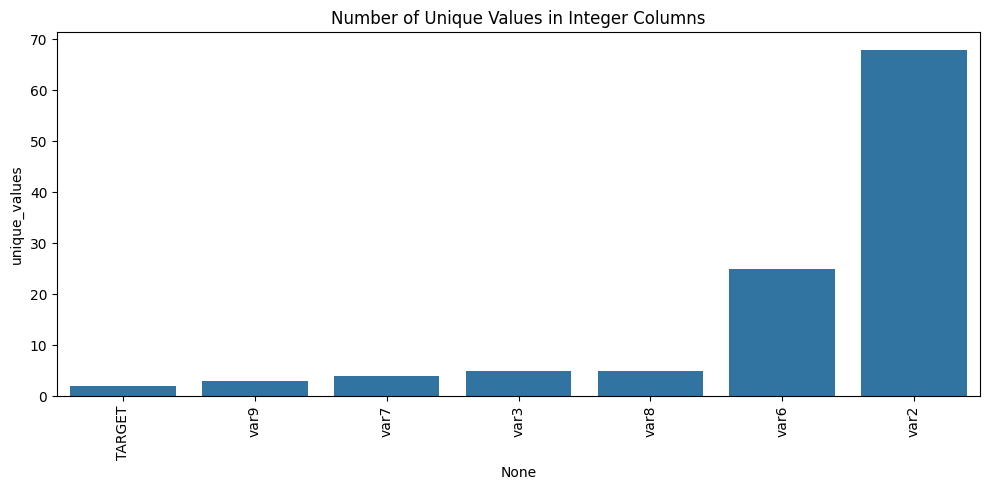

In [7]:
# Get count of unique values for integer columns and float columns
int_cols = [col for col in df_train.columns if df_train[col].dtype == 'int64']
float_cols = [col for col in df_train.columns if df_train[col].dtype == 'float64']
int_col_unique_counts = {col: df_train[col].nunique() for col in int_cols}
float_col_unique_counts = {col: df_train[col].nunique() for col in float_cols}

# Create a DataFrame for better visualization
int_unique_df = pd.DataFrame.from_dict(int_col_unique_counts, orient='index', columns=['unique_values'])
int_unique_df = int_unique_df.sort_values('unique_values')

print(f"Number of integer columns: {len(int_cols)}")
print("\nNumber of unique values in each integer column:")
display(int_unique_df)

# Create a DataFrame for better visualization
float_unique_df = pd.DataFrame.from_dict(float_col_unique_counts, orient='index', columns=['unique_values'])
float_unique_df = float_unique_df.sort_values('unique_values')

print(f"Number of float columns: {len(float_cols)}")
print("\nNumber of unique values in each float column:")
display(float_unique_df)

# Visualize the distribution of unique values
plt.figure(figsize=(10, 5))
sns.barplot(x=int_unique_df.index, y='unique_values', data=int_unique_df)
plt.xticks(rotation=90)
plt.title('Number of Unique Values in Integer Columns')
plt.tight_layout()
plt.show()

**On pourrait considérer var3, car7, var9 et var10 comme des variables à catégories, car elles ont peu de valeurs distinctes.**

target distribution
        TARGET      Ratio
TARGET                   
0        97992  93.327492
1         7006   6.672508


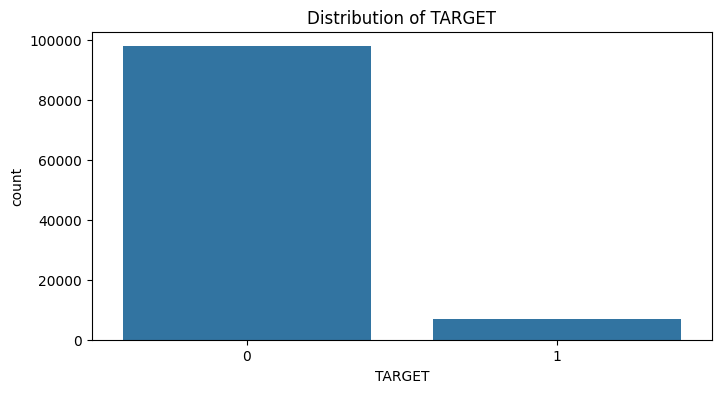

In [8]:
print("target distribution")
plt.figure(figsize=(8, 4))
print(pd.DataFrame({"TARGET": df_train["TARGET"].value_counts(), 
                    "Ratio": 100 * df_train["TARGET"].value_counts() / len(df_train)}))
sns.countplot(x=df_train["TARGET"], data=df_train)
plt.title(f"Distribution of TARGET")
# plt.tight_layout()
plt.show()

In [9]:
cat_cols = ["var3", "var7", "var9", "var10"]
num_cols = ["var1", "var2", "var4", "var5", "var6", "var8"]
int_col_unique_counts = {col: df_train[col].nunique() for col in int_cols}
float_col_unique_counts = {col: df_train[col].nunique() for col in float_cols}

TARGET distribution in train set
##########################################
TARGET
        TARGET      Ratio
TARGET                   
0        97992  93.327492
1         7006   6.672508


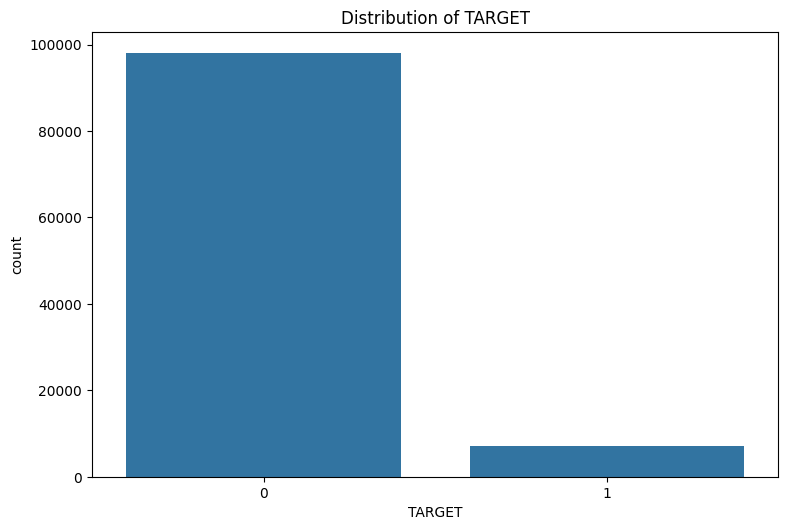

cat columns distribution in train set
##########################################
var3
       var3      Ratio
var3                  
0     88257  84.055887
1     11201  10.667822
2      3182   3.030534
3      1251   1.191451
4      1107   1.054306
##########################################
var7
       var7      Ratio
var7                  
0     99105  94.387512
1      3726   3.548639
2      1101   1.048591
3      1066   1.015257
##########################################
var9
       var9     Ratio
var9                 
0     99725  94.97800
1      3964   3.77531
2      1309   1.24669
##########################################
var10
       var10      Ratio
var10                  
0.0    60774  57.881102
1.0    18484  17.604145
2.0    13659  13.008819
3.0     6582   6.268691
4.0     2739   2.608621


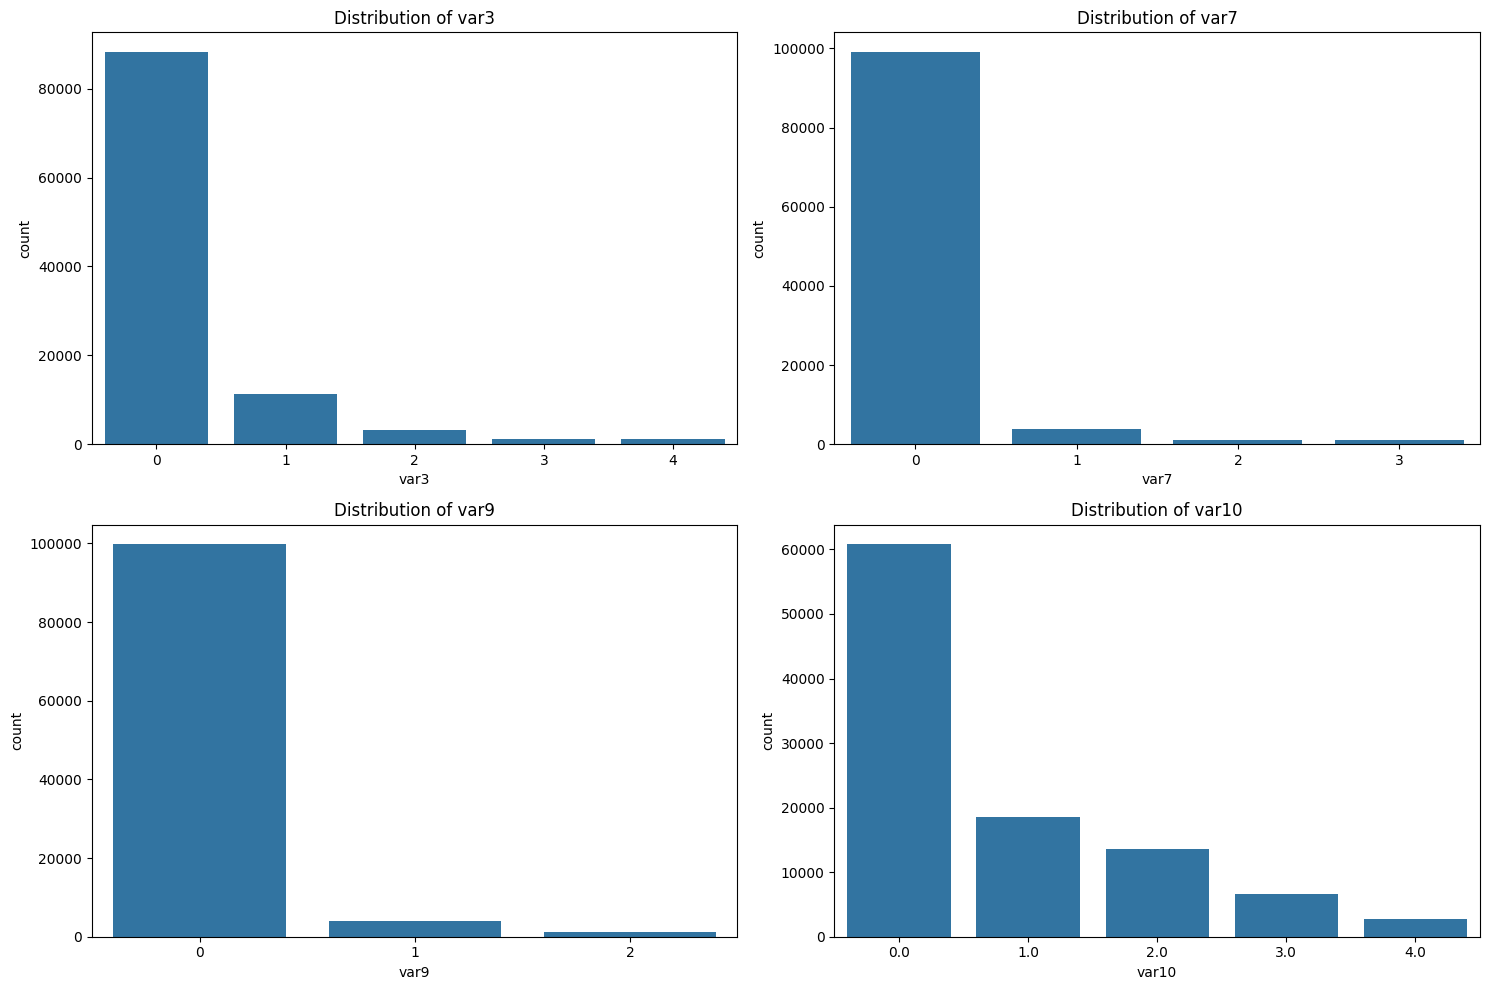

num columns distribution in train set
##########################################
var1
count    104998.000000
mean          0.321635
std           0.352608
min           0.000000
1%            0.000000
10%           0.003001
30%           0.043748
50%           0.155936
70%           0.446722
90%           0.982404
99%           1.092091
max           1.092091
Name: var1, dtype: float64
##########################################
var2
count    104998.000000
mean         52.231528
std          14.693805
min           0.000000
1%           24.000000
10%          33.000000
30%          44.000000
50%          52.000000
70%          60.000000
90%          72.000000
99%          87.000000
max          87.000000
Name: var2, dtype: float64
##########################################
var4
count    104998.000000
mean        317.474161
std         911.279548
min           0.000000
1%            0.000000
10%           0.030846
30%           0.213810
50%           0.366162
70%           0.648283
90%  

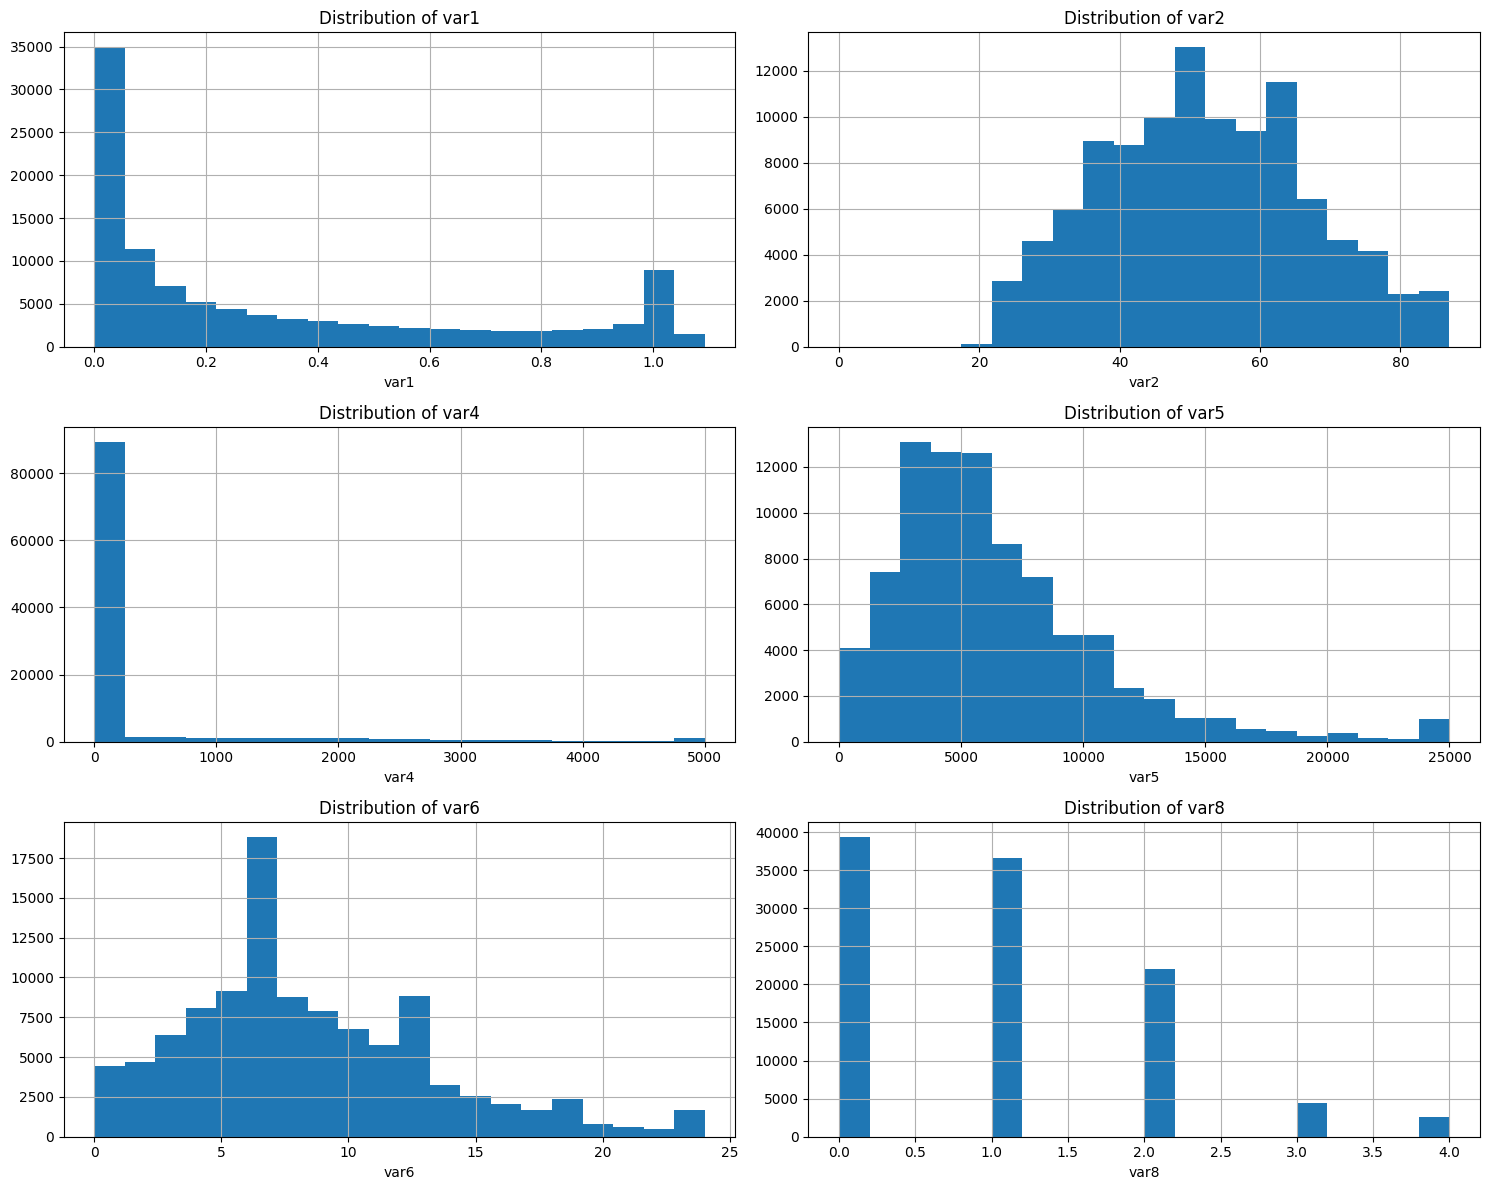

num columns without outliers distribution in train set
##########################################
var1 (filtered)
count    103948.000000
mean          0.313852
std           0.345733
min           0.000000
10%           0.002857
30%           0.042876
50%           0.151434
70%           0.432854
90%           0.964288
max           1.092091
Name: var1, dtype: float64
##########################################
var2 (filtered)
count    104998.000000
mean         52.231528
std          14.693805
min           0.000000
10%          33.000000
30%          44.000000
50%          52.000000
70%          60.000000
90%          72.000000
max          87.000000
Name: var2, dtype: float64
##########################################
var4 (filtered)
count    103948.000000
mean        270.194909
std         784.403078
min           0.000000
10%           0.029618
30%           0.211332
50%           0.361749
70%           0.630080
90%        1068.000000
max        4998.000000
Name: var4, dtype: float

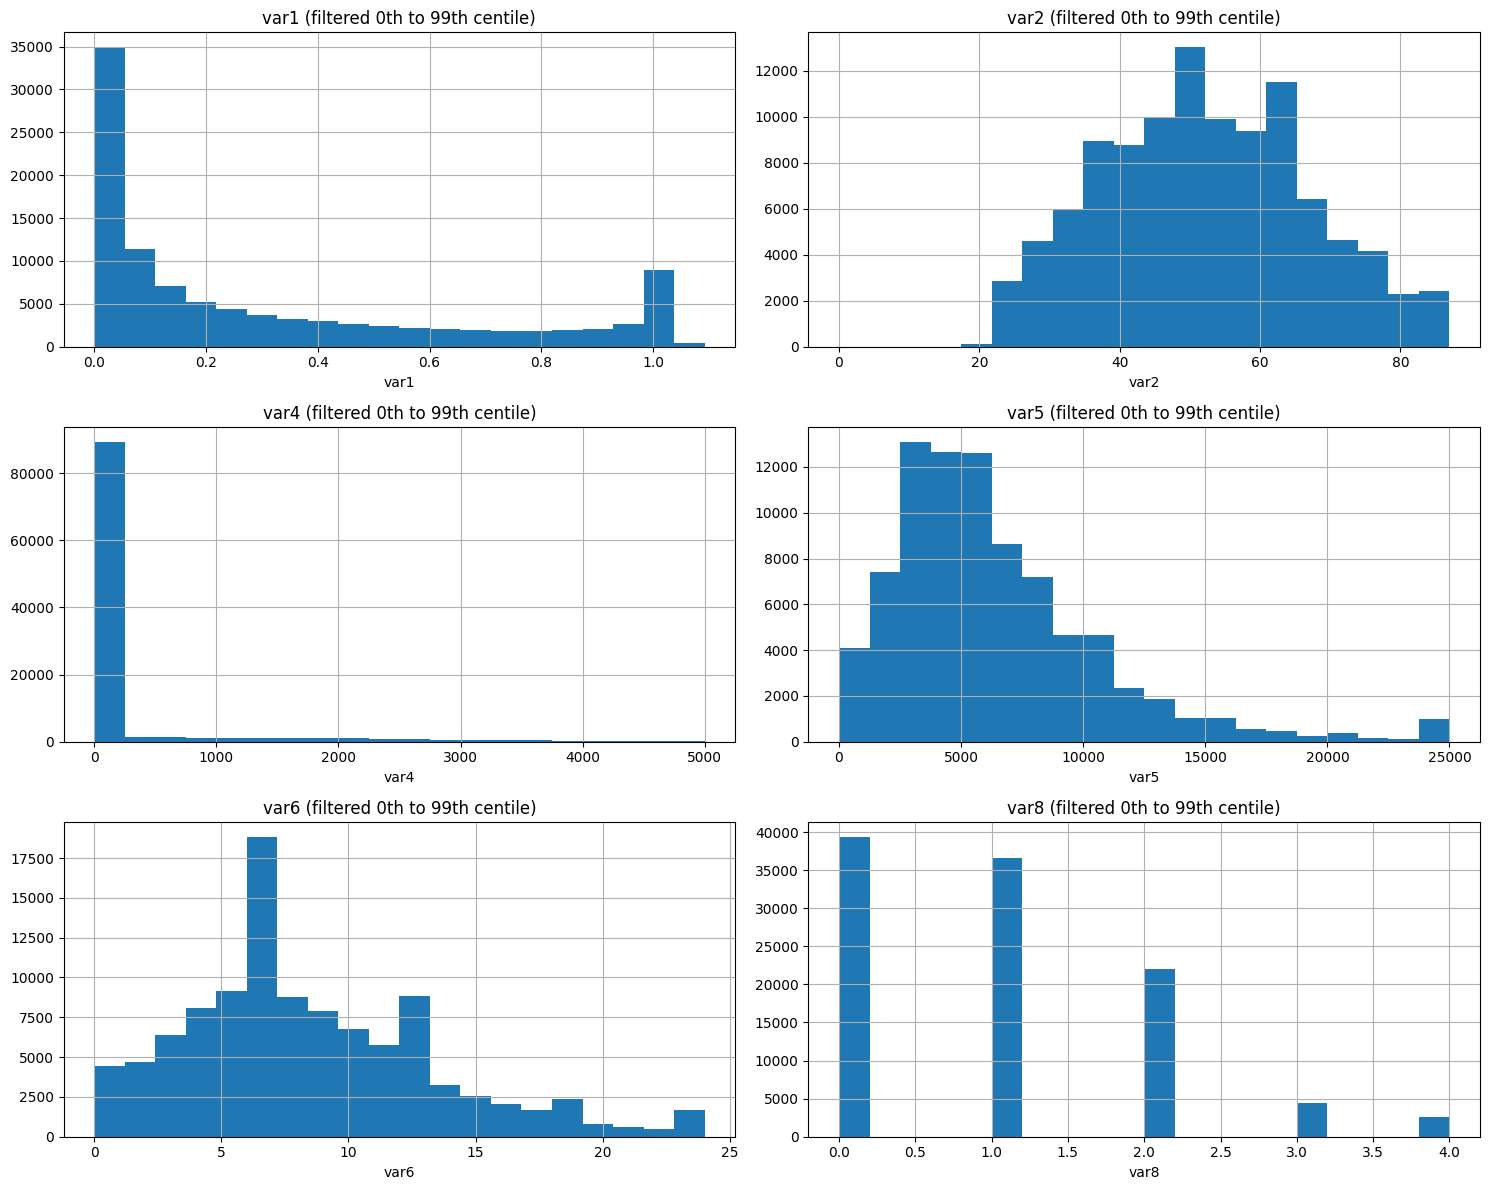

In [10]:
from math import ceil
# For categorical variables - display in 2 columns
def cat_summary(dataframe, cols):
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(cols):
        plt.subplot(2, 2, i+1)  # Arrange in 2x2 grid (adjust if you have more than 4 variables)
        print(f"##########################################\n{col}")
        print(pd.DataFrame({col: dataframe[col].value_counts(), "Ratio": 100 * dataframe[col].value_counts() / len(df_train)}))
        sns.countplot(x=dataframe[col], data=dataframe)
        plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


def num_summary(dataframe, cols):
    # For numerical variables - display in 2 columns
    num_rows = ceil(len(cols) / 2)  # Calculate number of rows needed
    plt.figure(figsize=(15, num_rows * 4))
    for i, col in enumerate(cols):
        quantiles = [0.01, 0.10, 0.30, 0.50, 0.70, 0.90, 0.99]
        print(f"##########################################\n{col}")
        print(dataframe[col].describe(quantiles).T)
        
        plt.subplot(num_rows, 2, i+1)  # Arrange in 2 columns
        dataframe[col].hist(bins=20)
        plt.xlabel(col)
        plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

def num_summary_filtered(dataframe, cols):
    # For filtered numerical variables
    num_rows = ceil(len(cols) / 2)  # Calculate number of rows needed
    plt.figure(figsize=(15, num_rows * 4))
    for i, col in enumerate(cols):
        # Calculate 0th and 99th centiles
        first_decile = dataframe[col].quantile(0.0)
        ninth_decile = dataframe[col].quantile(0.99)
        
        # Filter the dataframe
        filtered_df = dataframe[(dataframe[col] >= first_decile) & (dataframe[col] <= ninth_decile)]
        
        quantiles = [0.10, 0.30, 0.50, 0.70, 0.90]
        print(f"##########################################\n{col} (filtered)")
        print(filtered_df[col].describe(quantiles).T)
        
        plt.subplot(num_rows, 2, i+1)  # Arrange in 2 columns
        filtered_df[col].hist(bins=20)
        plt.xlabel(col)
        plt.title(f"{col} (filtered 0th to 99th centile)")
    plt.tight_layout()
    plt.show()

print("TARGET distribution in train set")
cat_summary(df_train, ["TARGET"])

print("cat columns distribution in train set")
cat_summary(df_train, cat_cols)

print("num columns distribution in train set")
num_summary(df_train, num_cols)

print("num columns without outliers distribution in train set")
num_summary_filtered(df_train, num_cols)


##########################################
var3
       var3      Ratio
var3                  
0     37761  35.963542
1      4832   4.601992
2      1416   1.348597
3       503   0.479057
4       490   0.466676
##########################################
var7
       var7      Ratio
var7                  
0     42557  40.531248
1      1517   1.444789
3       474   0.451437
2       454   0.432389
##########################################
var9
       var9      Ratio
var9                  
0     42671  40.639822
1      1767   1.682889
2       564   0.537153
##########################################
var10
       var10      Ratio
var10                  
0.0    26128  24.884284
1.0     7832   7.459190
2.0     5863   5.583916
3.0     2901   2.762910
4.0     1114   1.060973


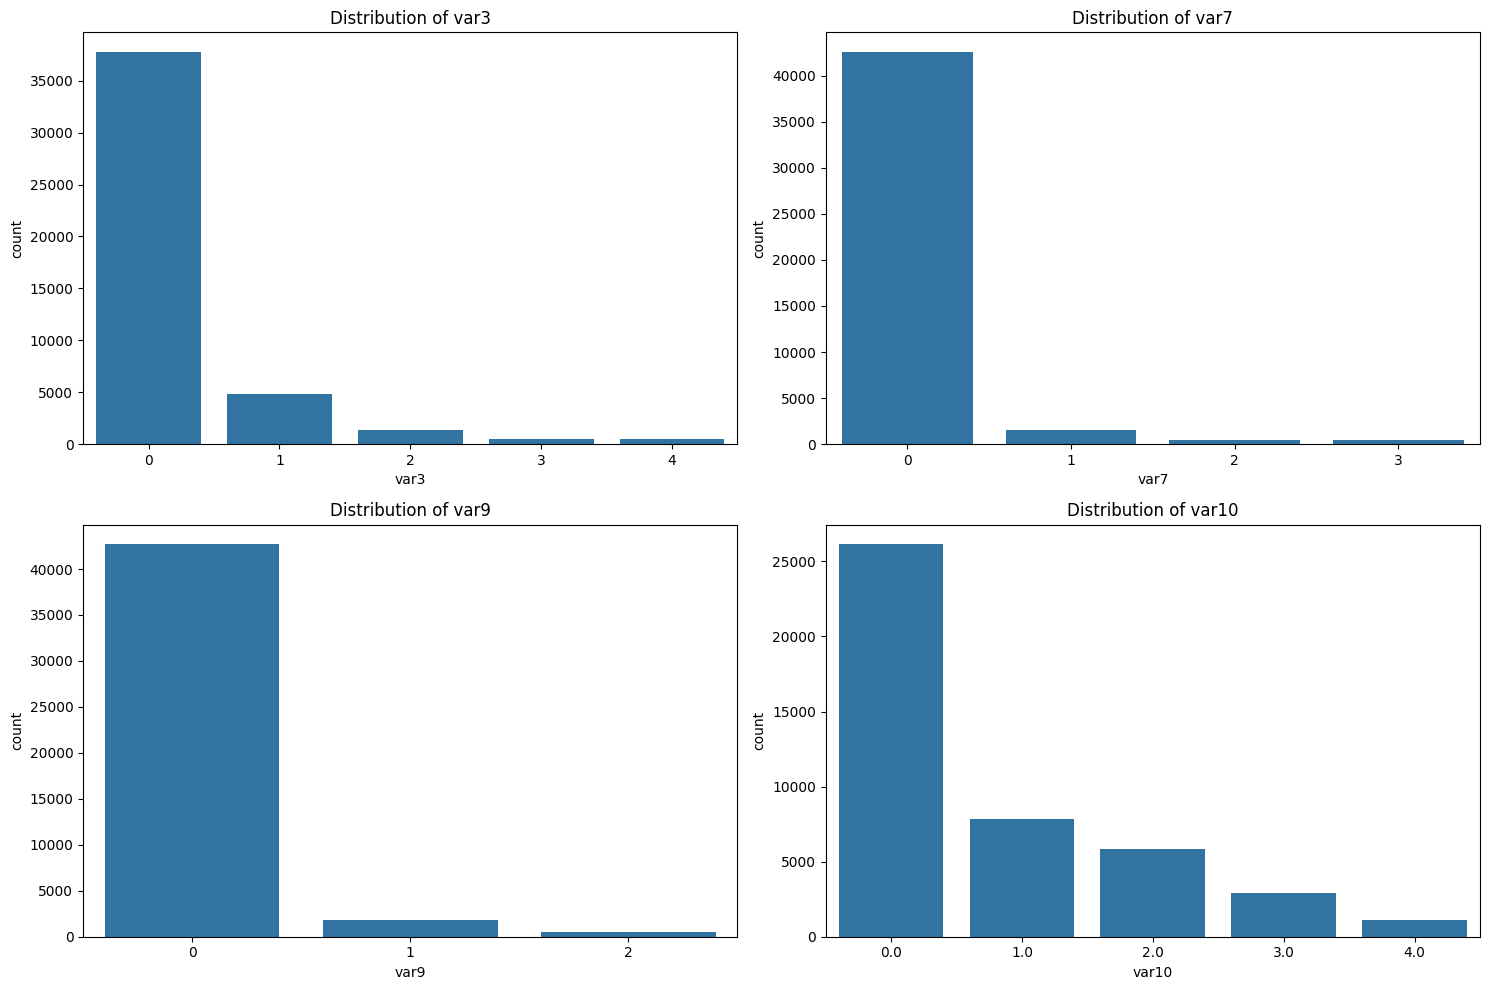

##########################################
var1
count    45002.000000
mean         0.317809
std          0.351013
min          0.000000
1%           0.000000
10%          0.002903
30%          0.042844
50%          0.150139
70%          0.441307
90%          0.978021
99%          1.092091
max          1.092091
Name: var1, dtype: float64
##########################################
var2
count    45002.000000
mean        52.344362
std         14.700572
min         21.000000
1%          24.000000
10%         33.000000
30%         44.000000
50%         52.000000
70%         61.000000
90%         72.000000
99%         87.000000
max         87.000000
Name: var2, dtype: float64
##########################################
var4
count    45002.000000
mean       315.019909
std        900.091576
min          0.000000
1%           0.000000
10%          0.030910
30%          0.213509
50%          0.367172
70%          0.651224
90%       1278.000000
99%       4920.980000
max       4998.030000
Name: var4

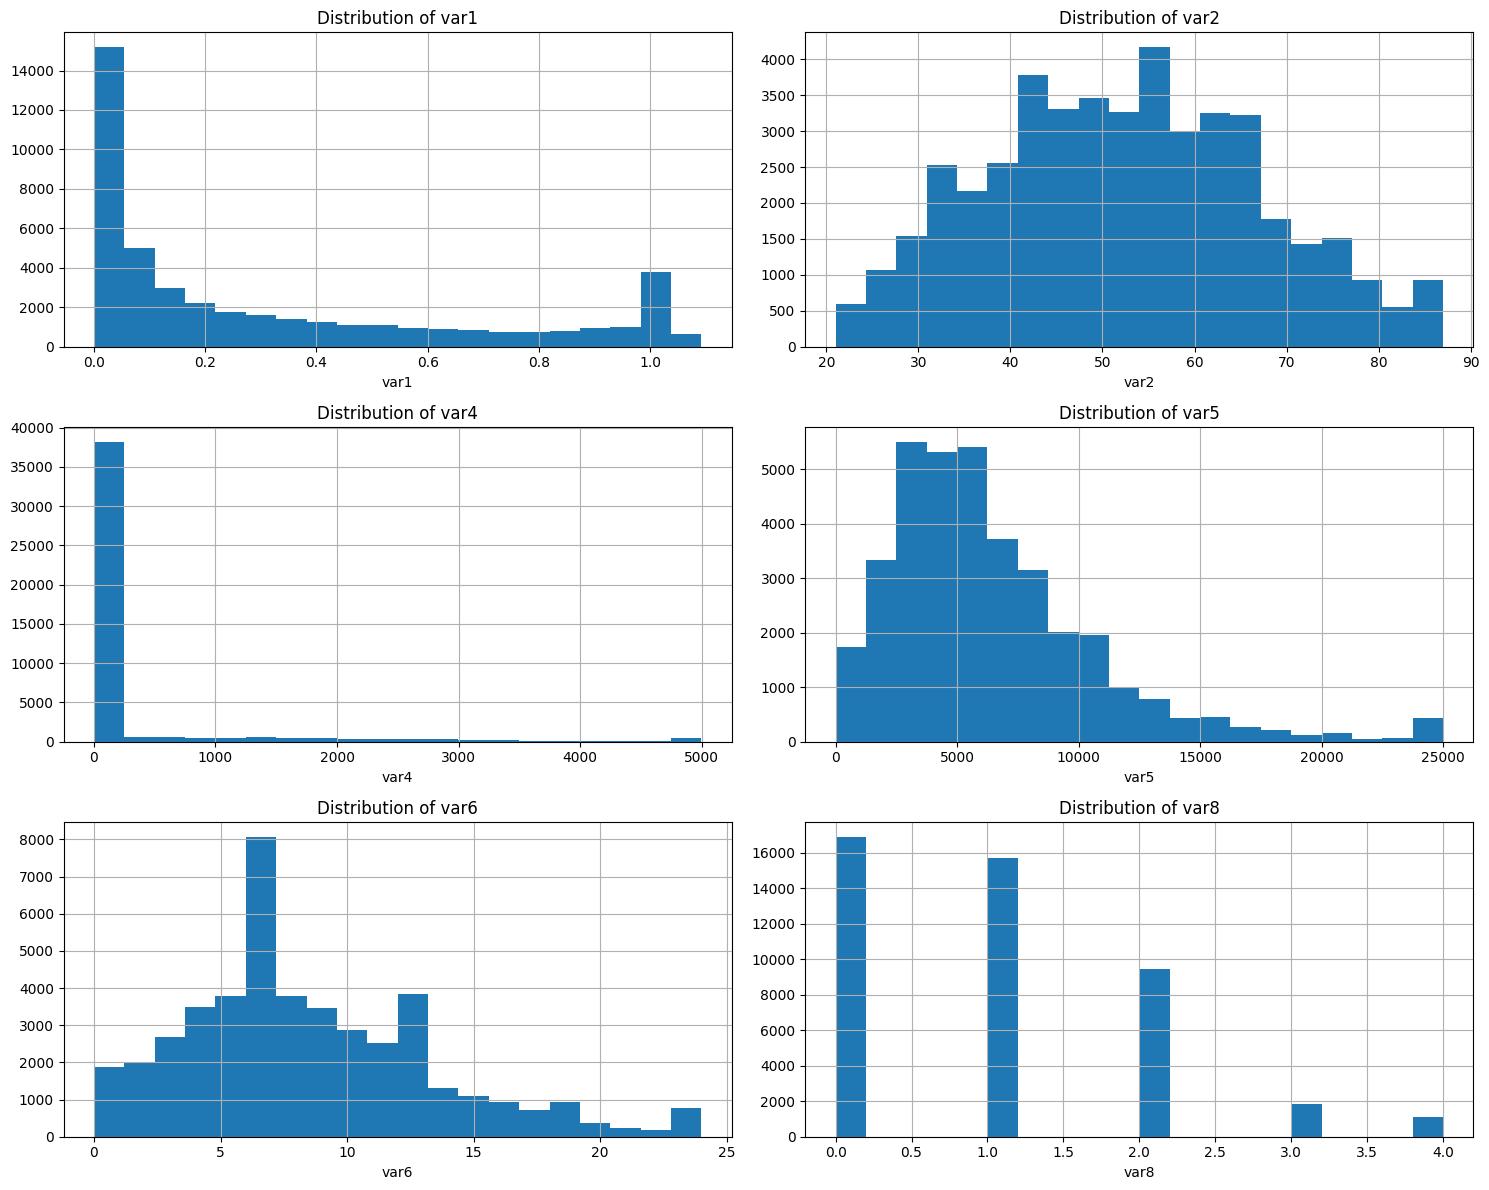

##########################################
var1 (filtered)
count    45002.000000
mean         0.317809
std          0.351013
min          0.000000
10%          0.002903
30%          0.042844
50%          0.150139
70%          0.441307
90%          0.978021
max          1.092091
Name: var1, dtype: float64
##########################################
var2 (filtered)
count    45002.000000
mean        52.344362
std         14.700572
min         21.000000
10%         33.000000
30%         44.000000
50%         52.000000
70%         61.000000
90%         72.000000
max         87.000000
Name: var2, dtype: float64
##########################################
var4 (filtered)
count    44551.000000
mean       267.632016
std        770.900211
min          0.000000
10%          0.030084
30%          0.211160
50%          0.363106
70%          0.633991
90%       1097.000000
max       4919.000000
Name: var4, dtype: float64
##########################################
var5 (filtered)
count    36043.000000
m

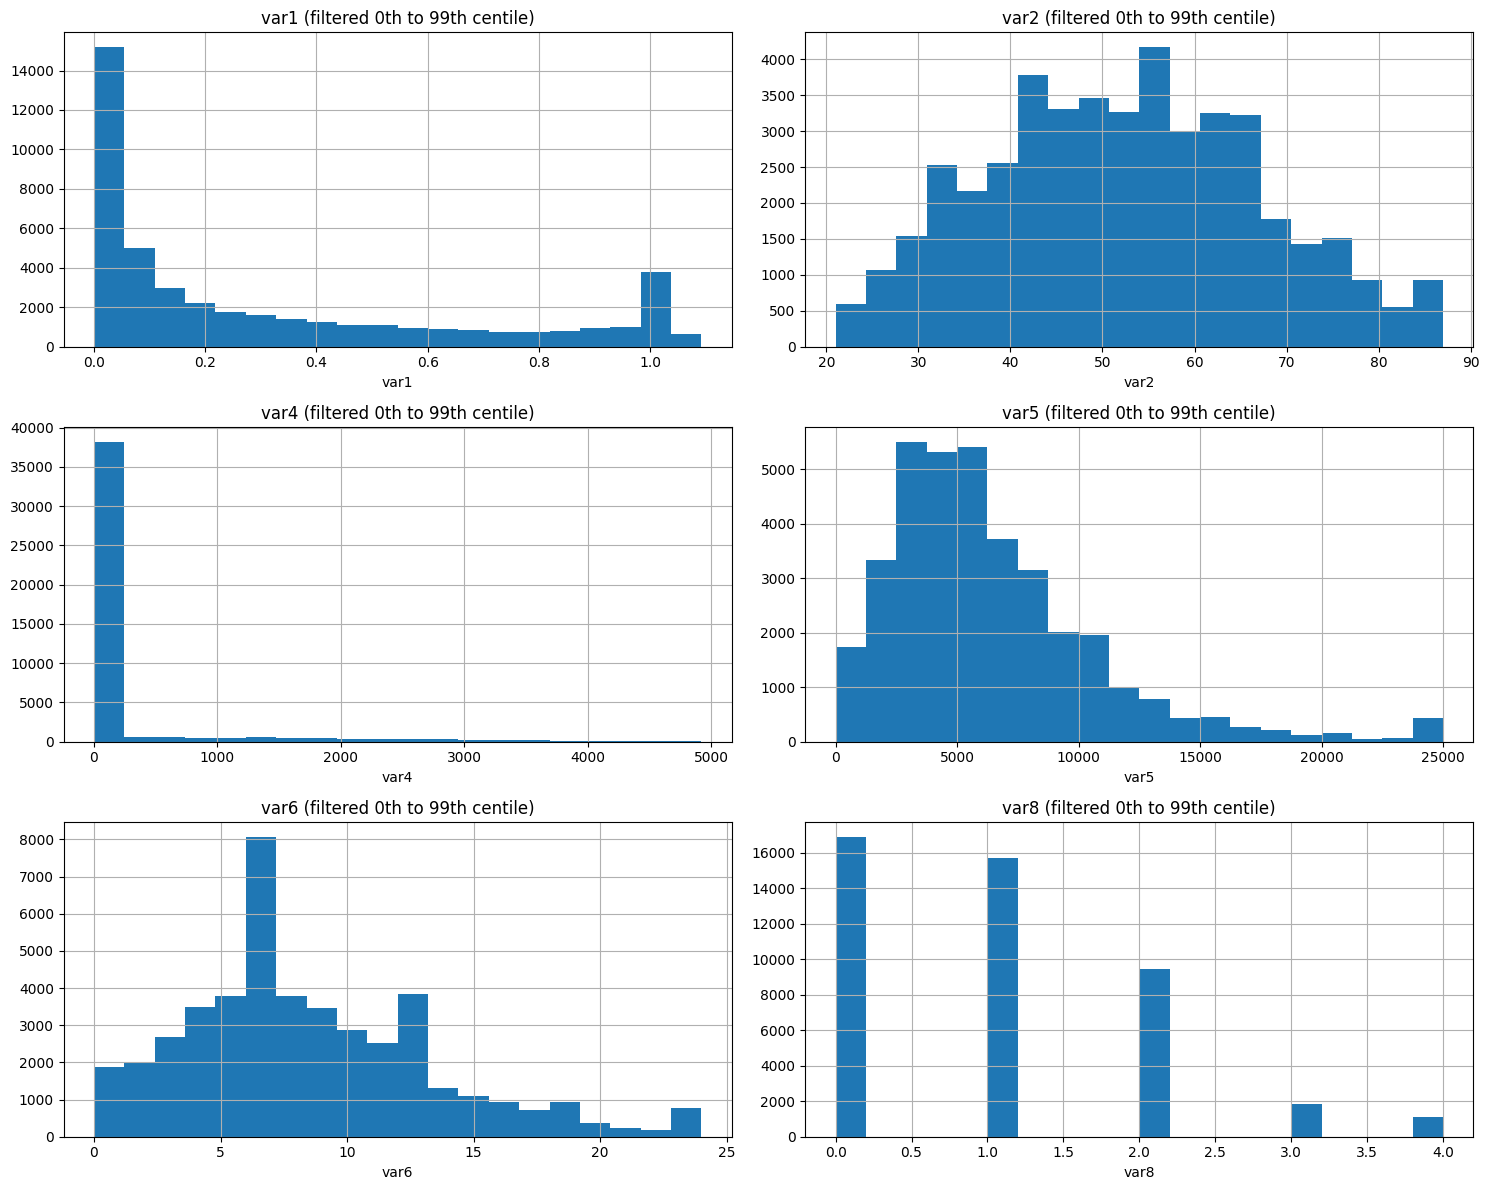

In [11]:
# and for test set:
cat_summary(df_test, cat_cols)
num_summary(df_test, num_cols)
num_summary_filtered(df_test, num_cols)

**var1, var5, var8 have extreme values, maybe delete these rows**

**var4 is not only extreme values but a very skewed repartition**

In [12]:
# Au vu des graphiques, retirer que le 99eme centile est interessant
def outlier_thresholds(dataframe, col_name, q1=0.0, q3=0.95):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit


def check_outlier(dataframe, col_name, ax=None):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    outliers = dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)]
    if ax is not None:
        sns.boxplot(x=dataframe[col_name], ax=ax)
        ax.set_title(f'Outliers in {col_name}')
    return outliers.any(axis=None)


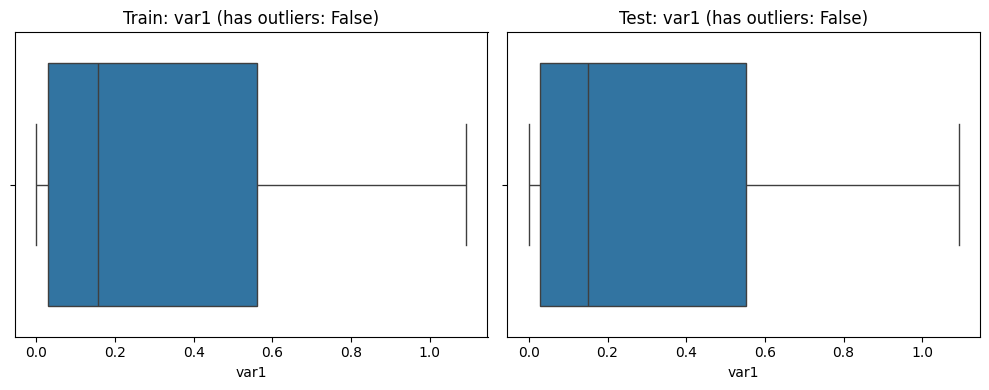

var1 - Train has outliers: False, Test has outliers: False


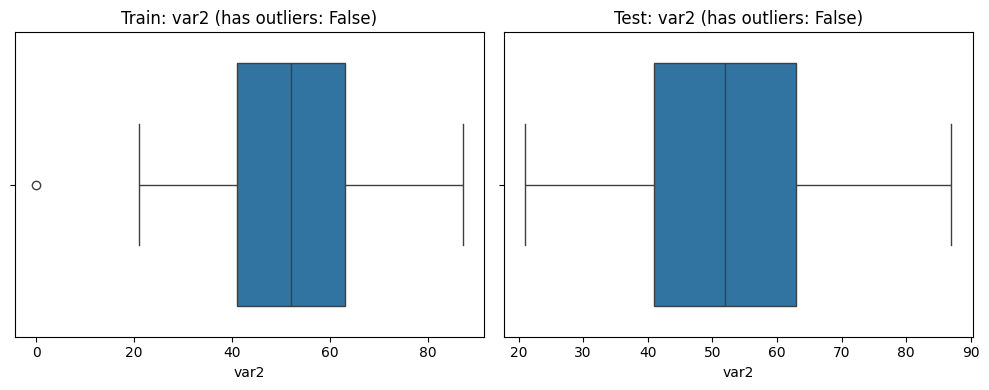

var2 - Train has outliers: False, Test has outliers: False


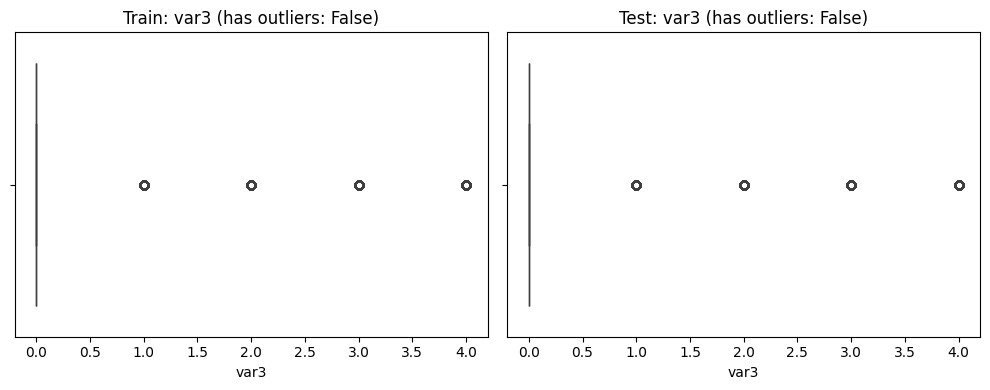

var3 - Train has outliers: False, Test has outliers: False


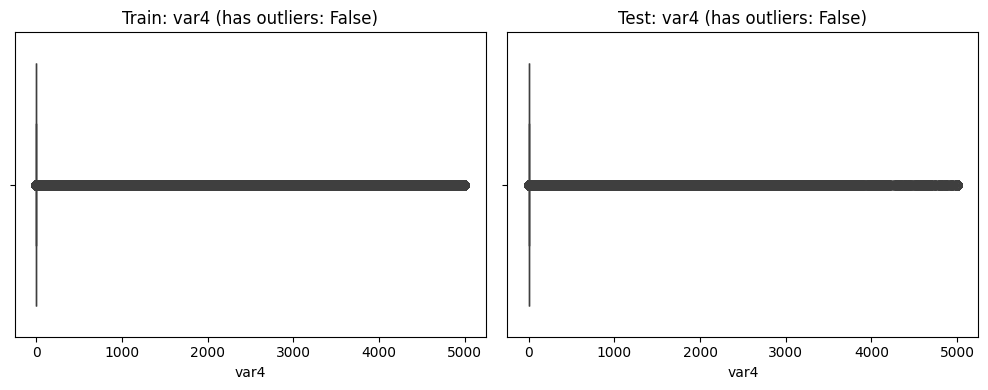

var4 - Train has outliers: False, Test has outliers: False


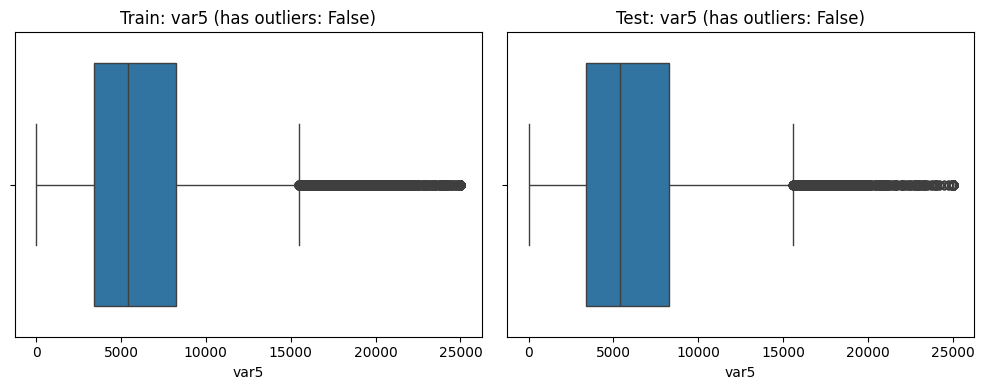

var5 - Train has outliers: False, Test has outliers: False


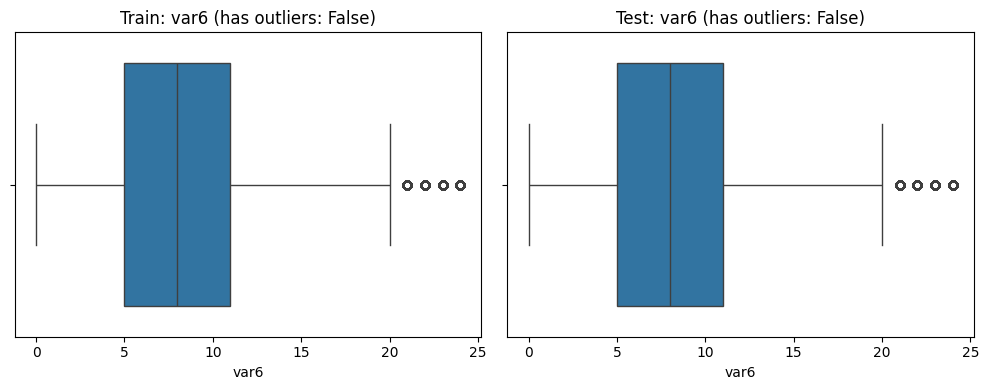

var6 - Train has outliers: False, Test has outliers: False


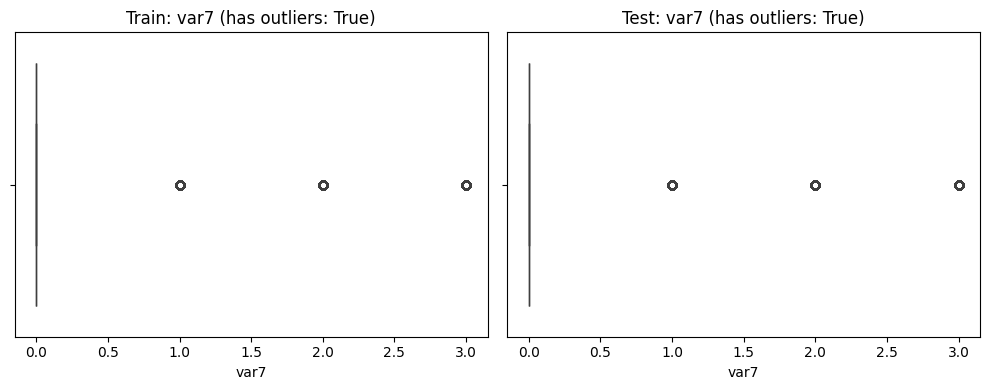

var7 - Train has outliers: True, Test has outliers: True


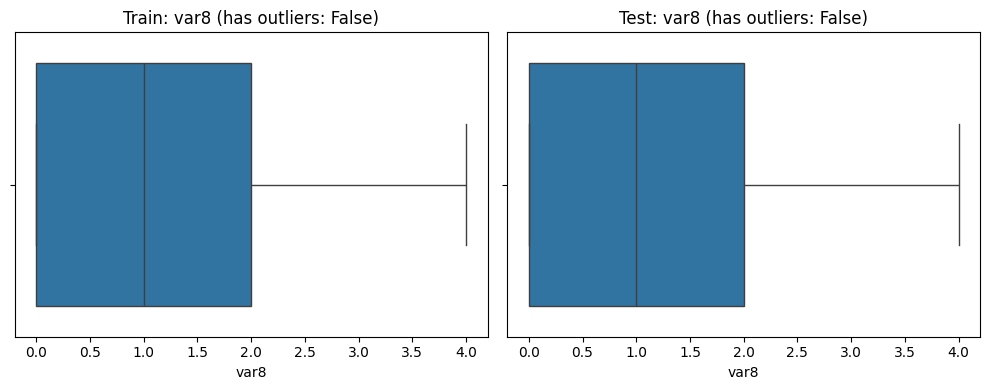

var8 - Train has outliers: False, Test has outliers: False


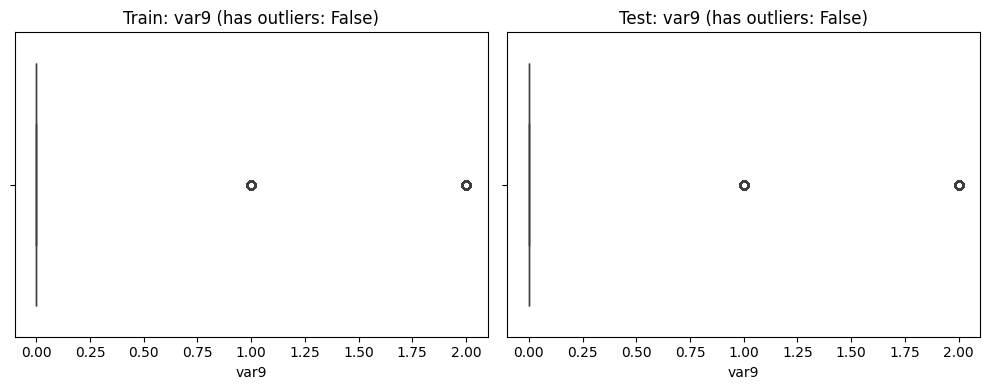

var9 - Train has outliers: False, Test has outliers: False


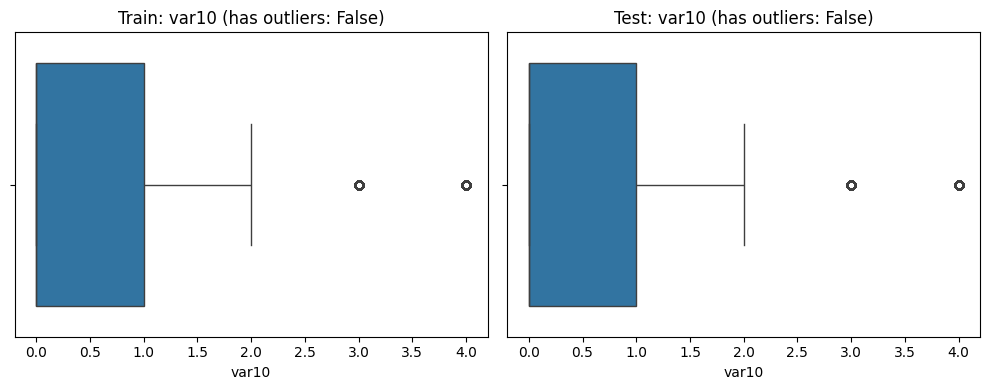

var10 - Train has outliers: False, Test has outliers: False


In [13]:
# Display outliers side by side for each variable
for col in df_train.columns:
    if col == "TARGET":
        continue
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    
    # Check and plot outliers for train set
    has_outlier_train = check_outlier(df_train, col, ax=ax1)
    ax1.set_title(f'Train: {col} (has outliers: {has_outlier_train})')
    
    # Check and plot outliers for test set
    has_outlier_test = check_outlier(df_test, col, ax=ax2)
    ax2.set_title(f'Test: {col} (has outliers: {has_outlier_test})')
    
    plt.tight_layout()
    plt.show()
    print(f"{col} - Train has outliers: {has_outlier_train}, Test has outliers: {has_outlier_test}")

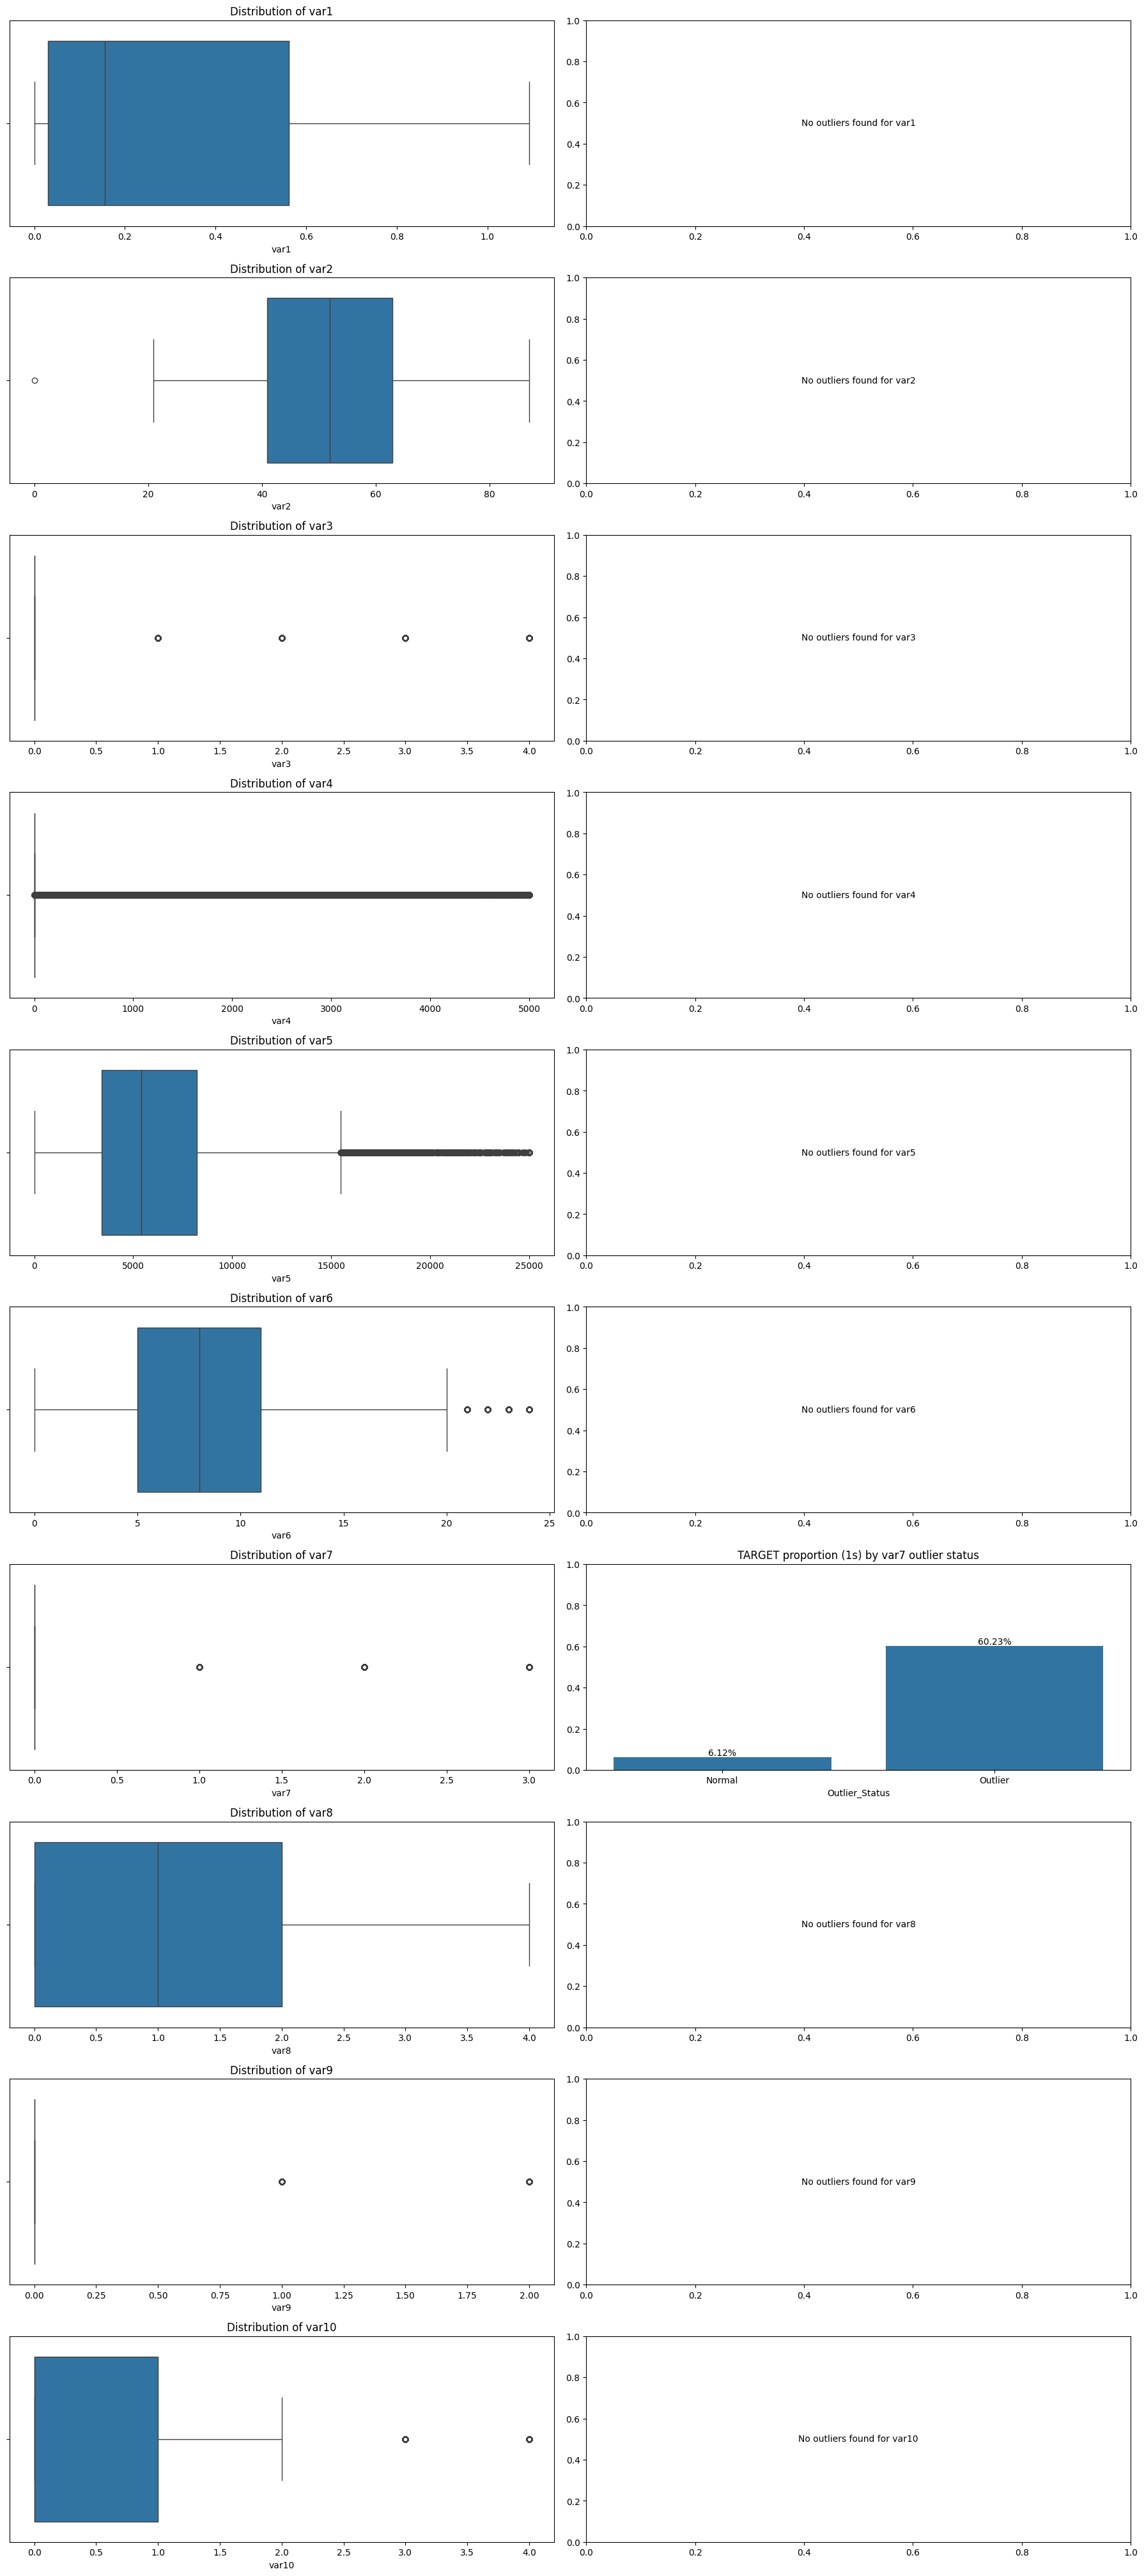

In [14]:
# Function to identify outliers for a given column
def get_outliers(dataframe, col_name, q1=0, q3=0.95):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    
    # Get mask for outliers
    outlier_mask = (dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)
    
    # Get outlier rows
    outlier_rows = dataframe[outlier_mask]
    
    return outlier_rows, outlier_mask

# Create a figure to display target distribution for outliers vs. non-outliers
plt.figure(figsize=(18, 4 * len(df_train.columns)))

for i, col in enumerate(df_train.columns):
    if col=="TARGET":
        continue
    # Get outliers
    outlier_rows, outlier_mask = get_outliers(df_train, col)
    
    # First subplot: Distribution of the variable
    plt.subplot(len(df_train.columns), 2, i*2+1)
    sns.boxplot(x=df_train[col])
    plt.title(f"Distribution of {col}")
    
    # Second subplot: TARGET proportion by outlier status
    plt.subplot(len(df_train.columns), 2, i*2+2)
    
    if outlier_mask.sum() > 0:
        # Create a categorical variable indicating outlier status
        outlier_status = ['Outlier' if x else 'Normal' for x in outlier_mask]
        
        # Calculate TARGET proportion for outliers vs non-outliers
        outlier_df = pd.DataFrame({
            'TARGET': df_train['TARGET'],
            'Outlier_Status': outlier_status
        })
        
        # Plot TARGET proportion (since it's binary 0/1)
        target_props = outlier_df.groupby('Outlier_Status')['TARGET'].mean()
        ax = sns.barplot(x=target_props.index, y=target_props.values)
        
        # Add percentage labels on bars
        for p in ax.patches:
            ax.annotate(f'{p.get_height():.2%}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'bottom')
            
        plt.title(f"TARGET proportion (1s) by {col} outlier status")
    else:
        plt.text(0.5, 0.5, f"No outliers found for {col}", 
                 horizontalalignment='center', verticalalignment='center')
    
    plt.ylim(0, 1)
    


plt.tight_layout()
plt.show()

Number of rows with at least one outlier: 0 (0.00%)


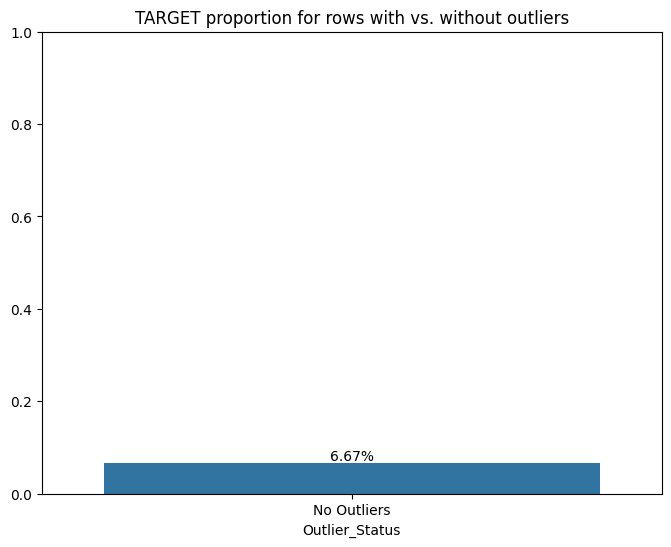

In [15]:
# Create a combined mask for rows with at least one outlier in any column
any_outlier_mask = pd.Series(False, index=df_train.index)
for col in num_cols:
    _, col_outlier_mask = get_outliers(df_train, col)
    any_outlier_mask = any_outlier_mask | col_outlier_mask

# Count how many rows have at least one outlier
outlier_count = any_outlier_mask.sum()
print(f"Number of rows with at least one outlier: {outlier_count} ({outlier_count*100/len(df_train):.2f}%)")

# Create a figure to analyze rows with any outliers
plt.figure(figsize=(8, 6))

outlier_status = ['Has Outlier' if x else 'No Outliers' for x in any_outlier_mask]
outlier_df = pd.DataFrame({'TARGET': df_train['TARGET'], 'Outlier_Status': outlier_status})

# Calculate and plot TARGET proportion
target_props = outlier_df.groupby('Outlier_Status')['TARGET'].mean()
ax = sns.barplot(x=target_props.index, y=target_props.values)

# Add percentage labels on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2%}', 
               (p.get_x() + p.get_width() / 2., p.get_height()), 
               ha = 'center', va = 'bottom')
    
plt.title("TARGET proportion for rows with vs. without outliers")
plt.ylim(0, 1)

plt.show()


Les outliers ont plus de classe 1 que le reste de la population : on ne peut pas le négliger ; avec certaines var qui ont plus de poids.

Pour les variables float : je pense qu'on peut remplacer par un threshold

Pour les int, je sais pas, car ce sont des catégories, mais threshold peut être approprié


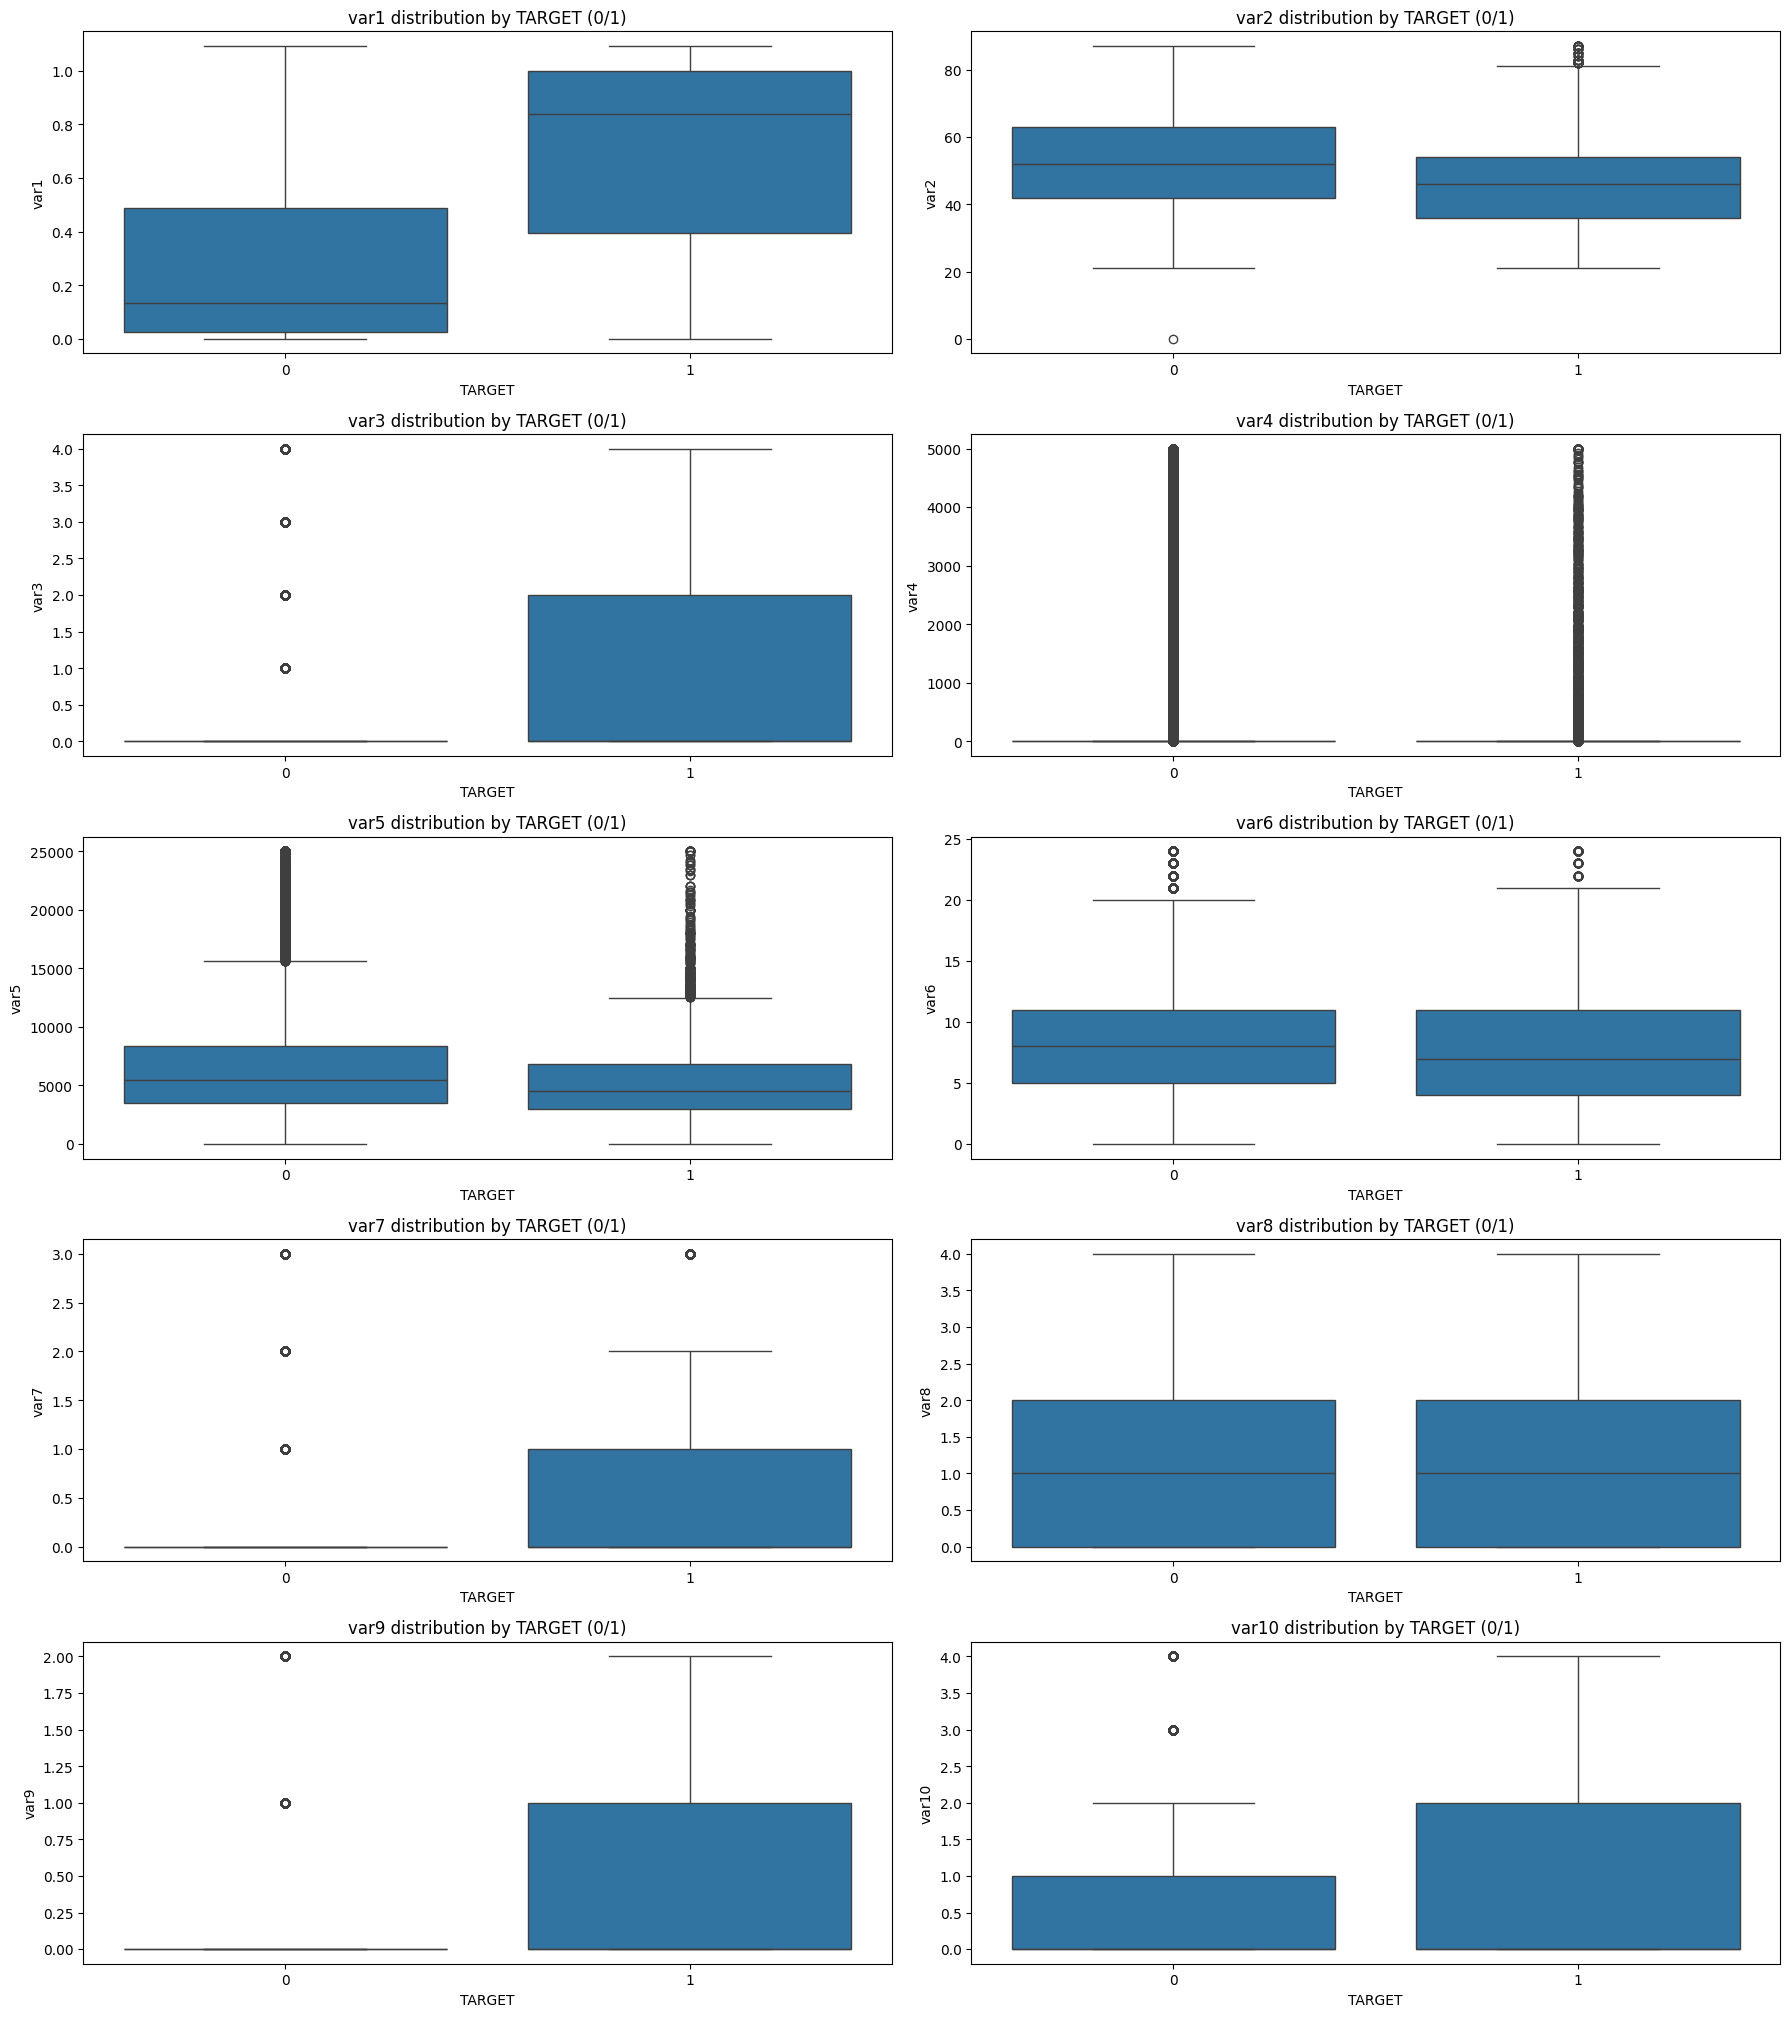

In [16]:
plt.figure(figsize=(18, 4 * len(df_train.columns)))

for i, col in enumerate(df_train.columns):
    if col == "TARGET":
        continue
    plt.subplot(len(df_train.columns), 2, i+1)

    # Show boxplot of the variable split by TARGET value (0/1)
    sns.boxplot(x='TARGET', y=col, data=df_train)
    plt.title(f"{col} distribution by TARGET (0/1)")

plt.tight_layout()
plt.show()


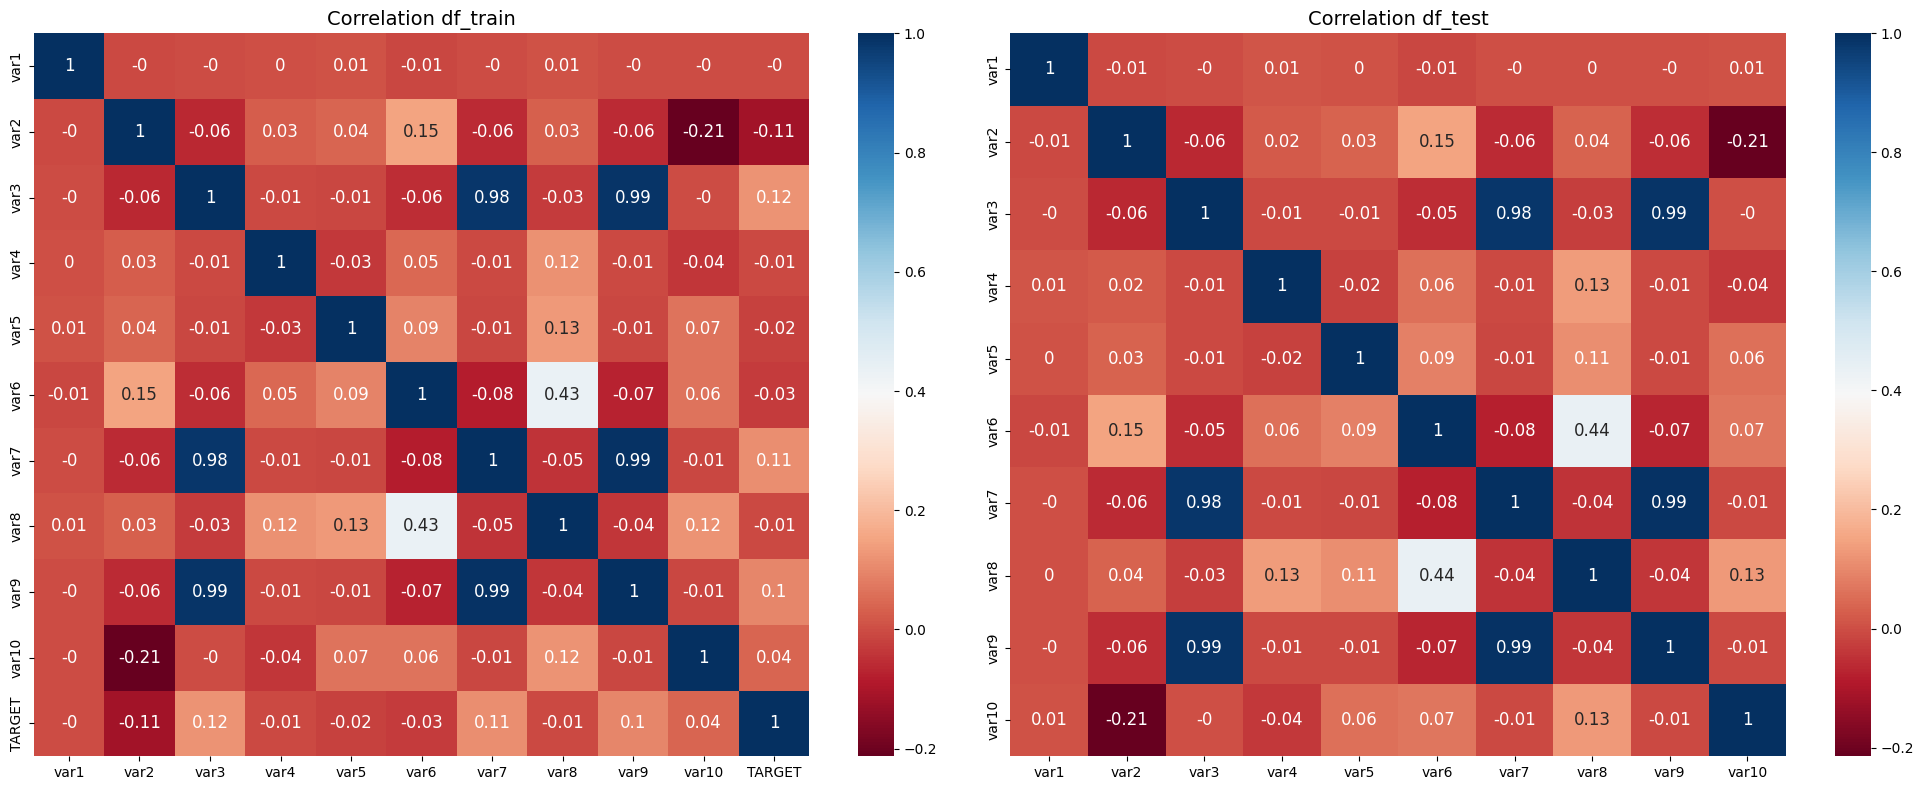

In [3]:
def plot_correlations_side_by_side(dataframe1, dataframe2, title1="Correlation df_train", title2="Correlation df_test"):
    # Compute correlations
    corr1 = dataframe1.corr()
    corr2 = dataframe2.corr()
    
    # Create figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot first correlation matrix
    corr_values1 = corr1.round(2)
    sns.heatmap(corr1, cmap="RdBu", annot=corr_values1, annot_kws={"size": 12}, ax=ax1)
    ax1.set_title(title1, fontsize=14)
    
    # Plot second correlation matrix
    corr_values2 = corr2.round(2)
    sns.heatmap(corr2, cmap="RdBu", annot=corr_values2, annot_kws={"size": 12}, ax=ax2)
    ax2.set_title(title2, fontsize=14)
    
    # Adjust layout
    plt.tight_layout()
    plt.show()


plot_correlations_side_by_side(df_train, df_test)

var3-var7-var9 très corrélées -> on peut en supprimer 2 des 3

var6-var8 assez corrélées, faudra faire du traitement pour ça

var2-var10 légère corrélation, garder à l'esprit

train et test ont les mêmes corrélations